# **DIDP model and dual bound declaration**

In [ ]:
%%writefile TSP_DIDP_model_declaration.py
import sys
import os
import numpy as np
import modified_didppy as m_dp

# --- GLOBALS ---
current_num_locations = 0
current_travel_cost = []

# --- READER ---
def read_tsp_cappart_format(file_path):
    with open(file_path, 'r') as f:
        values = f.read().split()
    iterator = iter(values)
    try:
        n = int(next(iterator))
        c = []
        for i in range(n):
            row = []
            for j in range(n):
                row.append(int(float(next(iterator))))
            c.append(row)
        return n, c
    except StopIteration:
        return 0, []

# --- MODEL DEFINITION ---
def creation_of_didp_model_function():
    n = current_num_locations
    c = current_travel_cost
    
    model = m_dp.Model(maximize=False, float_cost=True)
    customer = model.add_object_type(number=n)
    unvisited = model.add_set_var(object_type=customer, target=list(range(1, n)))
    location = model.add_element_var(object_type=customer, target=0)
    travel_time = model.add_float_table(c)

    for j in range(1, n):
        visit = m_dp.Transition(
            name=f"visit {j}",
            cost=travel_time[location, j] + m_dp.FloatExpr.state_cost(),
            preconditions=[unvisited.contains(j)],
            effects=[(unvisited, unvisited.remove(j)), (location, j)],
        )
        model.add_transition(visit)

    return_to_depot = m_dp.Transition(
        name="return",
        cost=travel_time[location, 0] + m_dp.FloatExpr.state_cost(),
        effects=[(location, 0)],
        preconditions=[unvisited.is_empty(), location != 0],
    )
    model.add_transition(return_to_depot)
    model.add_base_case([unvisited.is_empty(), location == 0])
    
    # --- DUAL BOUNDS ---
    min_to_val = [min(c[k][j] for k in range(n) if k != j) for j in range(n)]
    min_to = model.add_float_table(min_to_val)
    model.add_dual_bound(min_to[unvisited] + (location != 0).if_then_else(min_to[0], 0))
    
    min_from_val = [min(c[j][k] for k in range(n) if k != j) for j in range(n)]
    min_from = model.add_float_table(min_from_val)
    model.add_dual_bound(
        min_from[unvisited] + (location != 0).if_then_else(min_from[location], 0)
    )
    
    metadata = {
        "num_nodes": n,
        "distance_matrix": c,
        "unvisited_var": unvisited,
        "location_var": location,
    }
    return model, metadata

Overwriting TSP_DIDP_model_declaration.py


# **Worker**

In [1]:
%%writefile worker_profiling.py
import sys
import os
import json
import time
import threading

# --- CONFIGURATION ---
MEMORY_LIMIT_MB = 8000 

# --- 1. SETUP PATHS ---
sys.path.append(os.getcwd()) 

try:
    import psutil
    import modified_didppy as m_dp
    # Ensure this matches the filename in Step 1
    import TSP_DIDP_model_declaration as domain 
except ImportError as e:
    print(json.dumps({"status": "error", "message": f"Import Error: {e}"}))
    sys.exit(1)

# --- MEMORY GUARD ---
def memory_guard():
    process = psutil.Process(os.getpid())
    limit_bytes = MEMORY_LIMIT_MB * 1024 * 1024
    while True:
        try:
            if process.memory_info().rss > limit_bytes:
                os._exit(1)
            time.sleep(1)
        except: break

# --- MAIN LOGIC ---
if __name__ == "__main__":
    try:
        threading.Thread(target=memory_guard, daemon=True).start()

        # EXPECTS: script_name, instance, dir, time, nodes (5 total)
        if len(sys.argv) < 5: 
            raise ValueError(f"Args mismatch. Received {len(sys.argv)}: {sys.argv}")
        
        instance_name = sys.argv[1]
        data_dir = sys.argv[2] 
        time_limit = float(sys.argv[3])
        node_limit = int(sys.argv[4])

        # 1. Load Data
        file_path = os.path.join(data_dir, instance_name)
        if not os.path.exists(file_path):
             raise FileNotFoundError(f"Data file not found: {file_path}")

        n_val, c_val = domain.read_tsp_cappart_format(file_path)
        
        # 2. Update Globals
        domain.current_num_locations = n_val
        domain.current_travel_cost = c_val

        # 3. Create Model
        model, metadata = domain.creation_of_didp_model_function()
        
        # 4. Standard CABS Solver
        solver = m_dp.CABS(model, initial_beam_size=1, quiet=True)

        # 5. Profiling Loop
        history = [] 
        start_time = time.time()
        
        while True:
            if time.time() - start_time > time_limit: 
                break
            
            solution, is_terminated = solver.search_next()
            
            if solution.cost is not None:
                history.append((solution.expanded, solution.cost))
            
            if is_terminated:
                break
            if solution.expanded >= node_limit:
                break

        output = {
            "status": "success",
            "history": history,
            "duration": time.time() - start_time
        }
        print(json.dumps(output))

    except Exception as e:
        # This print ensures the Manager sees the error in stdout/stderr
        print(json.dumps({"status": "error", "message": str(e)}))
        sys.exit(1)

Overwriting worker_profiling.py


# **Manager**

In [ ]:
import subprocess
import pandas as pd
import numpy as np
import os
import sys
import json
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
NODE_EXPANSION_LIMIT = 100_000 
SOLVER_TIME_LIMIT = 900 
n_50_signal = False 

if n_50_signal:
    DATA_DIR = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Datasets\n50"
    # For single bound, we just iterate the target list directly
    TARGET_LIST_CSV = "TSP_single_dual_bound_50_cus_selected_results_1800s_lim.csv" 
    OUTPUT_FOLDER = "single_dual_dound_profiling_n50"
else:
    DATA_DIR = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Datasets\n20"
    TARGET_LIST_CSV = "TSP_single_dual_bound_20_cus_selected_results_1800s_lim.csv"
    OUTPUT_FOLDER = "single_dual_bound_Profiling_n20"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ==========================================
# HELPER: DENSE GAP CALCULATION (NO FLATLINE)
# ==========================================
def calculate_dense_gaps(history, optimal_cost, limit):
    history.sort(key=lambda x: x[0])
    
    sample_rate = 100  
    max_steps = limit // sample_rate
    
    # Init with NaN to represent "Stopped Recording"
    dense_gaps = np.full(max_steps, np.nan)
    
    current_cost = float('inf')
    hist_idx = 0
    
    for i in range(max_steps):
        current_node_count = (i + 1) * sample_rate
        
        # STOP RECORDING if we passed the actual history
        if hist_idx >= len(history) and history[-1][0] < current_node_count:
             break

        while hist_idx < len(history) and history[hist_idx][0] <= current_node_count:
            if history[hist_idx][1] < current_cost:
                current_cost = history[hist_idx][1]
            hist_idx += 1
            
        if current_cost == float('inf'):
            gap = 100.0 
        else:
            gap = (current_cost - optimal_cost) / optimal_cost * 100.0
            if gap < 0: gap = 0.0 
            
        dense_gaps[i] = gap
        
    return dense_gaps, sample_rate

# ==========================================
# MAIN EXECUTION
# ==========================================
def run_profiling_experiment():
    print(f"🔹 Starting Profiling (Max Nodes: {NODE_EXPANSION_LIMIT})...")
    
    if not os.path.exists(TARGET_LIST_CSV):
        print(f"❌ Target CSV missing: {TARGET_LIST_CSV}")
        return
        
    df_targets = pd.read_csv(TARGET_LIST_CSV)
    all_dense_gaps = [] 
    
    for i, row in df_targets.iterrows():
        instance = row['Instance']
        safe_name = instance.replace(".txt", "")
        output_csv_path = os.path.join(OUTPUT_FOLDER, f"gap_profile_{safe_name}.csv")
        
        # --- RESUME LOGIC ---
        if os.path.exists(output_csv_path):
            print(f"[{i+1}/{len(df_targets)}] Skipping {instance} (Already processed).")
            # Load existing data to include in final aggregation
            try:
                df_existing = pd.read_csv(output_csv_path)
                # Ensure the 'Gap_Percent' column exists
                if 'Gap_Percent' in df_existing.columns:
                    dense_gaps = df_existing['Gap_Percent'].values
                    # Ensure length matches current configuration (if changed mid-run, this might be issue, assume config constant)
                    expected_len = NODE_EXPANSION_LIMIT // 100
                    if len(dense_gaps) == expected_len:
                        all_dense_gaps.append(dense_gaps)
                    else:
                        print(f"   ⚠️ Warning: Existing file length mismatch. Ignoring {instance}.")
            except Exception as e:
                print(f"   ⚠️ Error reading existing file for {instance}: {e}")
            continue 
        # --------------------

        # --- SELECT OPTIMAL COST ---
        if n_50_signal:
            if 'Best Known Cost' in row:
                optimal_cost = row['Best Known Cost']
            else:
                # Fallback if column missing
                optimal_cost = row['Cost'] 
        else:
            optimal_cost = row['Cost']
        
        print(f"\n[{i+1}/{len(df_targets)}] Profiling {instance} (Opt: {optimal_cost})...")
        
        # FIXED: Removed "dummy_chrom" from the arguments list
        cmd = [
            sys.executable, "-u", "worker_profiling.py",
            instance, 
            DATA_DIR, 
            str(SOLVER_TIME_LIMIT), 
            str(NODE_EXPANSION_LIMIT)
        ]
        
        try:
            result = subprocess.run(cmd, capture_output=True, text=True)
            
            if result.returncode != 0:
                print(f"   ⚠️ Worker Failed")
                continue
                
            json_str = ""
            for line in result.stdout.split('\n'):
                if line.strip().startswith('{'):
                    json_str = line
            
            if not json_str:
                print("   ⚠️ No JSON output.")
                continue
                
            data = json.loads(json_str)
            if data['status'] != 'success':
                print(f"   ⚠️ Worker Error: {data.get('message')}")
                continue
                
            history = data['history']
            print(f"   -> Retrieved {len(history)} points.")
            
            dense_gaps, step_size = calculate_dense_gaps(history, optimal_cost, NODE_EXPANSION_LIMIT)
            all_dense_gaps.append(dense_gaps)
            
            # Save Individual
            df_hist = pd.DataFrame({
                'Node_Count': np.arange(step_size, NODE_EXPANSION_LIMIT + 1, step_size),
                'Gap_Percent': dense_gaps
            })
            df_hist.to_csv(output_csv_path, index=False)
            
        except Exception as e:
            print(f"   ❌ Error: {e}")

    # Aggregation
    if all_dense_gaps:
        print("\n📊 Aggregating Results...")
        gap_matrix = np.vstack(all_dense_gaps)
        # nanmean ignores the NaNs from stopped instances
        mean_gaps = np.nanmean(gap_matrix, axis=0)
        
        step_size = 100
        x_axis = np.arange(step_size, NODE_EXPANSION_LIMIT + 1, step_size)
        
        df_agg = pd.DataFrame({
            'Node_Count': x_axis,
            'Average_Gap_Percent': mean_gaps
        })
        
        agg_path = os.path.join(OUTPUT_FOLDER, "TSP_single_dual_bound_Average_Gaps_vs_Expansion.csv")
        df_agg.to_csv(agg_path, index=False)
        print(f"   ✅ Saved aggregated data to {agg_path}")
        
        plt.figure(figsize=(10, 6))
        plt.plot(x_axis, mean_gaps, label='Average Gap (%)', color='green')
        plt.xlabel('Nodes Expanded')
        plt.ylabel('Average Optimality Gap (%)')
        plt.title(f'Average gaps versus number of nodes expanded (N={"50" if n_50_signal else "20"})')
        plt.grid(True)
        plt.legend()
        plt.savefig(os.path.join(OUTPUT_FOLDER, "convergence_plot.png"))
        print(f"   ✅ Saved plot.")
        
    else:
        print("\n⚠️ No data collected.")

if __name__ == "__main__":
    run_profiling_experiment()

🔹 Starting Profiling (Max Nodes: 100000)...

[1/20] Profiling 1.txt (Opt: 390.0)...
   -> Retrieved 3 points.

[2/20] Profiling 12.txt (Opt: 399.0)...
   -> Retrieved 5 points.

[3/20] Profiling 18.txt (Opt: 384.0)...
   -> Retrieved 4 points.

[4/20] Profiling 19.txt (Opt: 400.0)...
   -> Retrieved 6 points.

[5/20] Profiling 21.txt (Opt: 367.0)...
   -> Retrieved 3 points.

[6/20] Profiling 26.txt (Opt: 389.0)...


# **Backup manager**

🔹 Starting Profiling (Max Nodes: 100000)...

[1/20] Profiling 11.txt (Opt: 574)...
   -> Retrieved 5 points.

[2/20] Profiling 14.txt (Opt: 575)...
   -> Retrieved 7 points.

[3/20] Profiling 22.txt (Opt: 599)...
   -> Retrieved 7 points.

[4/20] Profiling 31.txt (Opt: 538)...
   -> Retrieved 5 points.

[5/20] Profiling 33.txt (Opt: 624)...
   -> Retrieved 5 points.

[6/20] Profiling 39.txt (Opt: 527)...
   -> Retrieved 8 points.

[7/20] Profiling 4.txt (Opt: 602)...
   -> Retrieved 8 points.

[8/20] Profiling 46.txt (Opt: 576)...
   -> Retrieved 4 points.

[9/20] Profiling 48.txt (Opt: 550)...
   -> Retrieved 4 points.

[10/20] Profiling 50.txt (Opt: 577)...
   -> Retrieved 4 points.

[11/20] Profiling 52.txt (Opt: 607)...
   -> Retrieved 6 points.

[12/20] Profiling 53.txt (Opt: 555)...
   -> Retrieved 5 points.

[13/20] Profiling 54.txt (Opt: 552)...
   -> Retrieved 4 points.

[14/20] Profiling 59.txt (Opt: 537)...
   -> Retrieved 6 points.

[15/20] Profiling 61.txt (Opt: 600)...
  

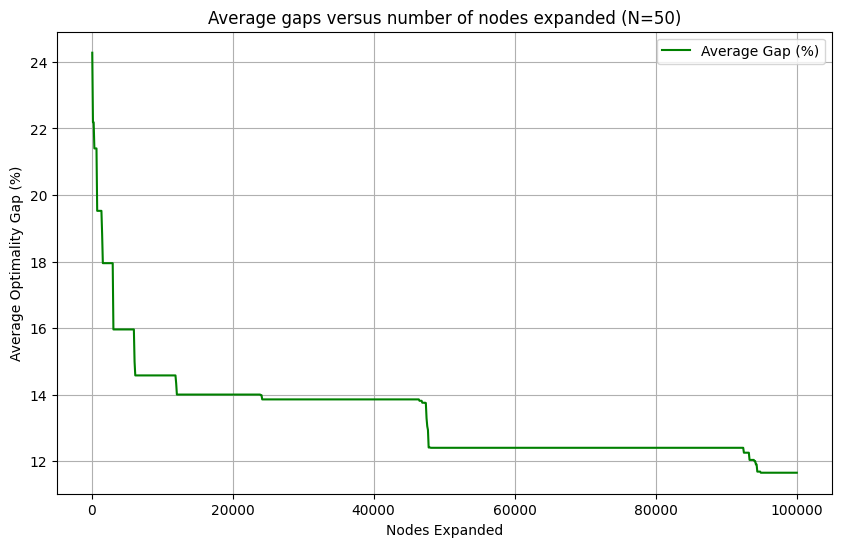

In [1]:
import subprocess
import pandas as pd
import numpy as np
import os
import sys
import json
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
NODE_EXPANSION_LIMIT = 100_000 
SOLVER_TIME_LIMIT = 1800 
n_50_signal = True 

if n_50_signal:
    DATA_DIR = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Datasets\n50"
    TARGET_LIST_CSV = "TSP_single_dual_bound_50_cus_selected_results_1800s_lim.csv" 
    OUTPUT_FOLDER = "single_dual_dound_profiling_n50"
else:
    DATA_DIR = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\1_TSP_dual_bounds_and_models\Datasets\n20"
    TARGET_LIST_CSV = "TSP_single_dual_bound_20_cus_selected_results_1800s_lim.csv"
    OUTPUT_FOLDER = "single_dual_bound_profiling_n20"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ==========================================
# HELPER: DENSE GAP CALCULATION (NO FLATLINE)
# ==========================================
def calculate_dense_gaps(history, optimal_cost, limit):
    history.sort(key=lambda x: x[0])
    
    sample_rate = 100  
    max_steps = limit // sample_rate
    
    dense_gaps = np.full(max_steps, np.nan)
    
    current_cost = float('inf')
    hist_idx = 0
    
    for i in range(max_steps):
        current_node_count = (i + 1) * sample_rate
        
        if hist_idx >= len(history) and history[-1][0] < current_node_count:
             break

        while hist_idx < len(history) and history[hist_idx][0] <= current_node_count:
            if history[hist_idx][1] < current_cost:
                current_cost = history[hist_idx][1]
            hist_idx += 1
            
        if current_cost == float('inf'):
            gap = 100.0 
        else:
            gap = (current_cost - optimal_cost) / optimal_cost * 100.0
            if gap < 0: gap = 0.0 
            
        dense_gaps[i] = gap
        
    return dense_gaps, sample_rate

# ==========================================
# MAIN EXECUTION
# ==========================================
def run_profiling_experiment():
    print(f"🔹 Starting Profiling (Max Nodes: {NODE_EXPANSION_LIMIT})...")
    
    if not os.path.exists(TARGET_LIST_CSV):
        print(f"❌ Target CSV missing: {TARGET_LIST_CSV}")
        return
        
    df_targets = pd.read_csv(TARGET_LIST_CSV)
    all_dense_gaps = [] 
    
    for i, row in df_targets.iterrows():
        instance = row['Instance']
        
        if n_50_signal:
            if 'Best Known Cost' in row:
                optimal_cost = row['Best Known Cost']
            else:
                optimal_cost = row['Cost'] 
        else:
            optimal_cost = row['Cost']
        
        print(f"\n[{i+1}/{len(df_targets)}] Profiling {instance} (Opt: {optimal_cost})...")
        
        # NOTE: EXACTLY 5 arguments passed here
        cmd = [
            sys.executable, "-u", "worker_profiling.py",
            instance, 
            DATA_DIR, 
            str(SOLVER_TIME_LIMIT), 
            str(NODE_EXPANSION_LIMIT)
        ]
        
        try:
            result = subprocess.run(cmd, capture_output=True, text=True)
            
            if result.returncode != 0:
                print(f"   ⚠️ Worker Failed (Code {result.returncode})")
                # PRINT ERROR DETAILS FOR DEBUGGING
                print(f"   🔎 STDERR: {result.stderr}")
                print(f"   🔎 STDOUT: {result.stdout}")
                continue
                
            json_str = ""
            for line in result.stdout.split('\n'):
                if line.strip().startswith('{'):
                    json_str = line
            
            if not json_str:
                print("   ⚠️ No JSON output.")
                print(f"   🔎 Raw Output: {result.stdout}")
                continue
                
            data = json.loads(json_str)
            if data['status'] != 'success':
                print(f"   ⚠️ Worker Error: {data.get('message')}")
                continue
                
            history = data['history']
            print(f"   -> Retrieved {len(history)} points.")
            
            dense_gaps, step_size = calculate_dense_gaps(history, optimal_cost, NODE_EXPANSION_LIMIT)
            all_dense_gaps.append(dense_gaps)
            
            # Save Individual
            df_hist = pd.DataFrame({
                'Node_Count': np.arange(step_size, NODE_EXPANSION_LIMIT + 1, step_size),
                'Gap_Percent': dense_gaps
            })
            safe_name = instance.replace(".txt", "")
            df_hist.to_csv(os.path.join(OUTPUT_FOLDER, f"gap_profile_{safe_name}.csv"), index=False)
            
        except Exception as e:
            print(f"   ❌ Error: {e}")

    if all_dense_gaps:
        print("\n📊 Aggregating Results...")
        gap_matrix = np.vstack(all_dense_gaps)
        mean_gaps = np.nanmean(gap_matrix, axis=0)
        
        step_size = 100
        x_axis = np.arange(step_size, NODE_EXPANSION_LIMIT + 1, step_size)
        
        df_agg = pd.DataFrame({
            'Node_Count': x_axis,
            'Average_Gap_Percent': mean_gaps
        })
        
        agg_path = os.path.join(OUTPUT_FOLDER, "TSP_Average_Gaps_vs_Expansion.csv")
        df_agg.to_csv(agg_path, index=False)
        print(f"   ✅ Saved aggregated data to {agg_path}")
        
        plt.figure(figsize=(10, 6))
        plt.plot(x_axis, mean_gaps, label='Average Gap (%)', color='green')
        plt.xlabel('Nodes Expanded')
        plt.ylabel('Average Optimality Gap (%)')
        plt.title(f'Average gaps versus number of nodes expanded (N={"50" if n_50_signal else "20"})')
        plt.grid(True)
        plt.legend()
        plt.savefig(os.path.join(OUTPUT_FOLDER, "convergence_plot.png"))
        print(f"   ✅ Saved plot.")
        
    else:
        print("\n⚠️ No data collected.")

if __name__ == "__main__":
    run_profiling_experiment()